In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS_SYN = ROOT / "results_n2000"
RESULTS_NAT = ROOT / "natural_abstraction" / "results_natural"
FIG_DIR = ROOT / "figures_analysis"
FIG_DIR.mkdir(exist_ok=True)

print("Python:", sys.executable)
print("ROOT:", ROOT)
print("RESULTS_NAT:", RESULTS_NAT)
print("RESULTS_NAT exists:", RESULTS_NAT.exists())

NameError: name 'sys' is not defined

In [14]:
SUBTYPE_ORDER = ["real", "painting", "cartoon", "sketch", "abstract"]

CLASS_ORDER = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [15]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches="tight")
    plt.show()


def order_subtypes(df, subtype_col="subtype"):
    subtype_to_level = {k: i for i, k in enumerate(SUBTYPE_ORDER)}
    d = df.copy()
    d["level"] = d[subtype_col].map(subtype_to_level)
    return d.sort_values("level")


def barplot(df, xcol, ycol, title, ylabel, rotation=30, fname=None, order=None):
    d = df.copy()
    if order is not None:
        d[xcol] = pd.Categorical(d[xcol], categories=order, ordered=True)
        d = d.sort_values(xcol)

    plt.figure()
    plt.bar(d[xcol].astype(str).tolist(), d[ycol].tolist())
    plt.grid(axis="y")
    plt.xlabel("")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=rotation)

    if fname:
        savefig(fname)
    else:
        plt.show()


def lineplot_by_transform(df, ycol, title, ylabel, fname=None):
    plt.figure()
    for t in sorted(df["transform"].unique()):
        sub = df[df["transform"] == t].sort_values("level")
        plt.plot(sub["level"].tolist(), sub[ycol].tolist(), marker="o", label=t)
    plt.grid(True)
    plt.xlabel("Severity Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title="Transformation")

    if fname:
        savefig(fname)
    else:
        plt.show()


def heatmap_from_pivot(mat, title, fname=None):
    plt.figure(figsize=(8, 5))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(mat.columns)), [str(c) for c in mat.columns], rotation=45, ha="right")
    plt.yticks(range(len(mat.index)), [str(i) for i in mat.index])
    plt.title(title)

    if fname:
        savefig(fname)
    else:
        plt.show()


def top_confusions(conf_df, top_k=15):
    rows = []
    for true_label in conf_df.index:
        for pred_label in conf_df.columns:
            if true_label == pred_label:
                continue
            val = conf_df.loc[true_label, pred_label]
            if val > 0:
                rows.append((true_label, pred_label, val))
    out = pd.DataFrame(rows, columns=["true", "pred", "count"])
    return out.sort_values("count", ascending=False).head(top_k)

In [16]:
# --- YOLO natural baseline ---
yolo_nat_raw = pd.read_csv(RESULTS_NAT / "baseline_natural_yolo26.csv")
yolo_nat_overall = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_yolo26_overall.csv")
yolo_nat_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_yolo26_by_subtype.csv")
yolo_nat_class = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_yolo26_by_class.csv")
yolo_nat_class_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_yolo26_by_class_subtype.csv")
yolo_conf_overall = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_yolo26_overall.csv", index_col=0)

# --- YOLO synthetic corruptions ---
yolo_syn_app = pd.read_csv(RESULTS_NAT / "summary_corruptions_appearance_yolo26.csv")
yolo_syn_geo = pd.read_csv(RESULTS_NAT / "summary_corruptions_geometry_yolo26.csv")

print("YOLO natural overall:")
display(yolo_nat_overall)

print("YOLO by subtype:")
display(yolo_nat_subtype.head())

print("YOLO by class:")
display(yolo_nat_class.head())

YOLO natural overall:


,accuracy,macro_f1,n
0,0.943194,0.947038,933


YOLO by subtype:


,subtype,accuracy,macro_f1,mean_confidence,n
0,abstract,0.900621,0.910121,0.948510,161.0
1,cartoon,0.952381,0.942111,0.973489,168.0
2,painting,0.955414,0.947102,0.981080,157.0
3,real,0.947735,0.962141,0.961453,287.0
4,sketch,0.956250,0.951593,0.968317,160.0


YOLO by class:


,true_label_name,accuracy,mean_confidence,n
0,airplane,0.913793,0.934555,116.0
1,automobile,0.938596,0.951923,114.0
2,bird,0.915094,0.957401,106.0
3,cat,0.945946,0.971666,111.0
4,deer,0.935484,0.979700,93.0


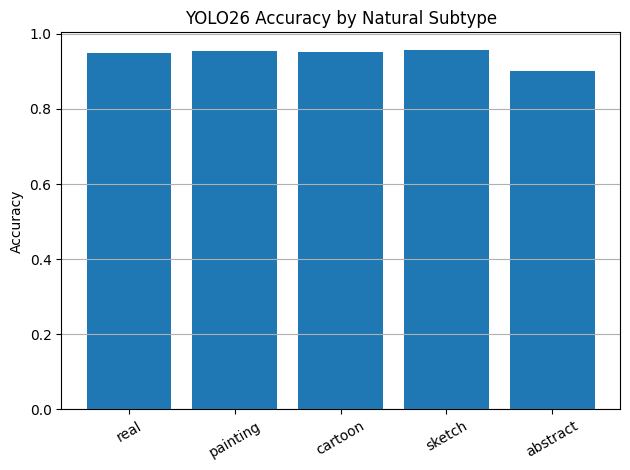

In [17]:
barplot(
    yolo_nat_subtype,
    "subtype",
    "accuracy",
    "YOLO26 Accuracy by Natural Subtype",
    "Accuracy",
    fname="natural_yolo_subtype_accuracy.png",
    order=SUBTYPE_ORDER
)

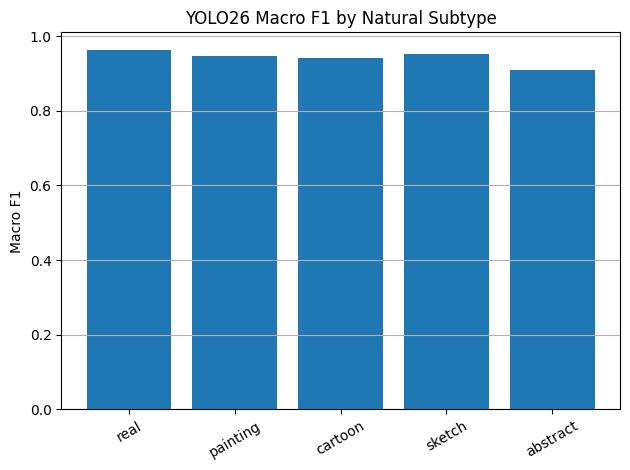

In [18]:
barplot(
    yolo_nat_subtype,
    "subtype",
    "macro_f1",
    "YOLO26 Macro F1 by Natural Subtype",
    "Macro F1",
    fname="natural_yolo_subtype_macro_f1.png",
    order=SUBTYPE_ORDER
)

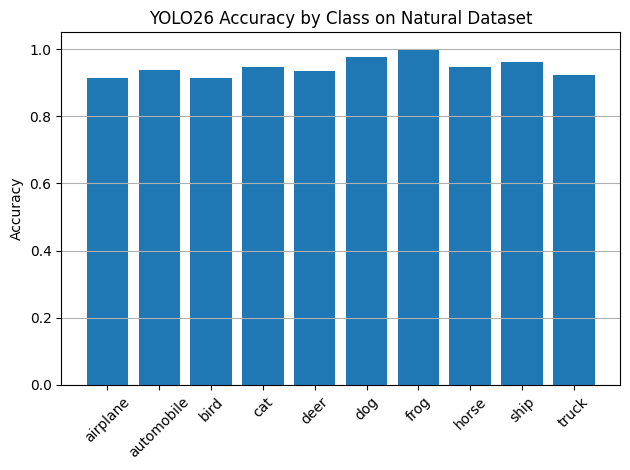

In [19]:
barplot(
    yolo_nat_class,
    "true_label_name",
    "accuracy",
    "YOLO26 Accuracy by Class on Natural Dataset",
    "Accuracy",
    rotation=45,
    fname="natural_yolo_class_accuracy.png",
    order=CLASS_ORDER
)

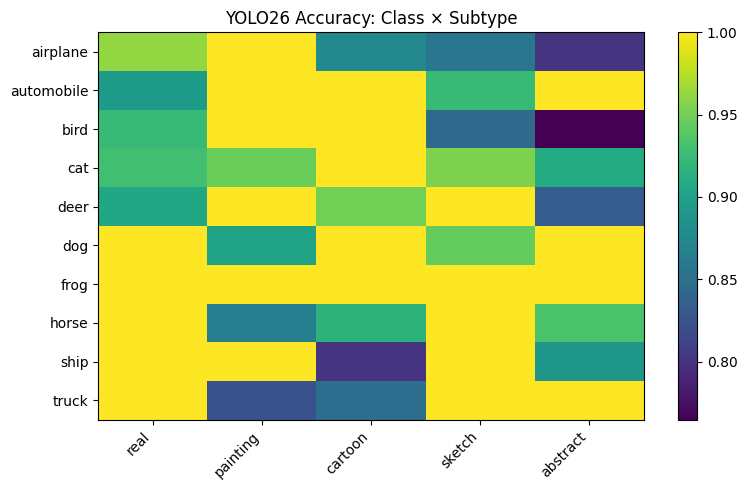

In [20]:
yolo_acc_heat = yolo_nat_class_subtype.pivot(
    index="true_label_name",
    columns="subtype",
    values="accuracy"
).reindex(index=CLASS_ORDER, columns=SUBTYPE_ORDER)

heatmap_from_pivot(
    yolo_acc_heat,
    "YOLO26 Accuracy: Class × Subtype",
    "heatmap_yolo_accuracy_class_subtype.png"
)

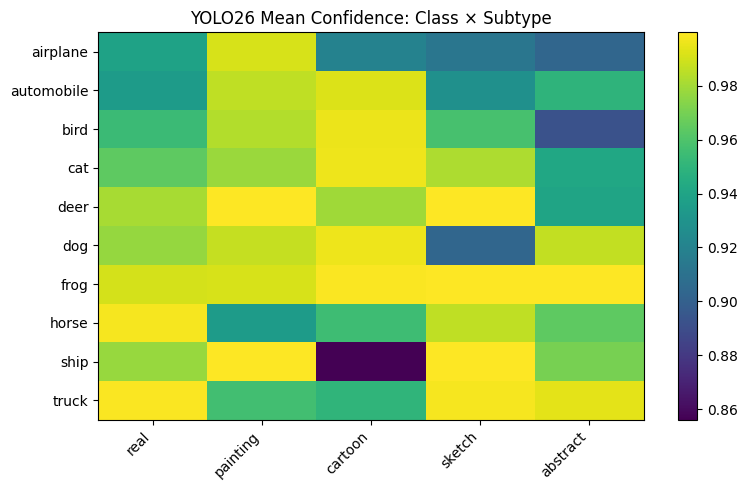

In [21]:
yolo_conf_heat = yolo_nat_class_subtype.pivot(
    index="true_label_name",
    columns="subtype",
    values="mean_confidence"
).reindex(index=CLASS_ORDER, columns=SUBTYPE_ORDER)

heatmap_from_pivot(
    yolo_conf_heat,
    "YOLO26 Mean Confidence: Class × Subtype",
    "heatmap_yolo_confidence_class_subtype.png"
)

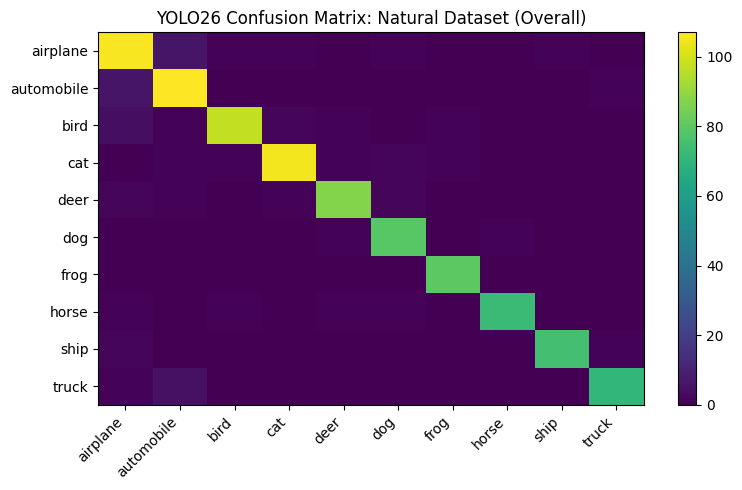

In [23]:
heatmap_from_pivot(
    yolo_conf_overall.reindex(index=CLASS_ORDER, columns=CLASS_ORDER),
    "YOLO26 Confusion Matrix: Natural Dataset (Overall)",
    "confusion_overall_yolo_natural.png"
)

In [24]:
top_confusions(yolo_conf_overall, top_k=20)

,true,pred,count
0,airplane,automobile,6
5,automobile,airplane,6
30,truck,automobile,5
7,bird,airplane,4
9,bird,cat,2
15,cat,dog,2
20,deer,dog,2
17,deer,airplane,2
27,ship,airplane,2
8,bird,automobile,1


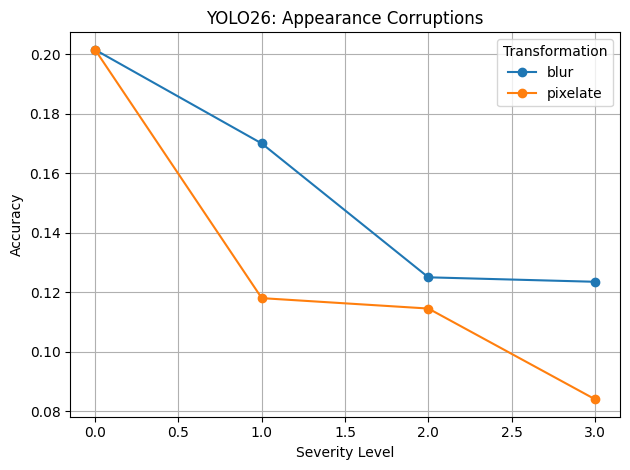

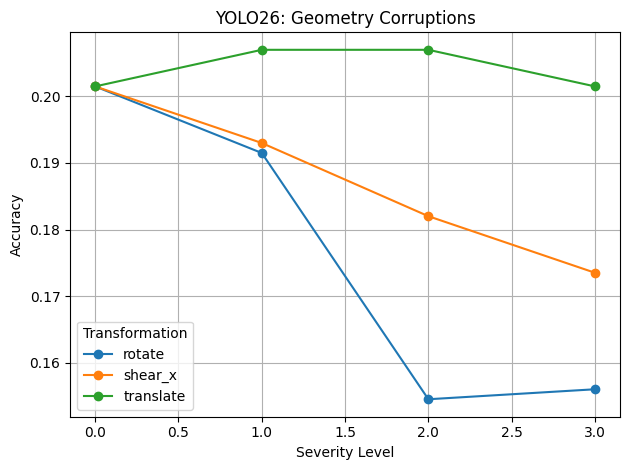

In [25]:
lineplot_by_transform(
    yolo_syn_app,
    "accuracy",
    "YOLO26: Appearance Corruptions",
    "Accuracy",
    "synthetic_yolo_appearance_accuracy.png"
)

lineplot_by_transform(
    yolo_syn_geo,
    "accuracy",
    "YOLO26: Geometry Corruptions",
    "Accuracy",
    "synthetic_yolo_geometry_accuracy.png"
)

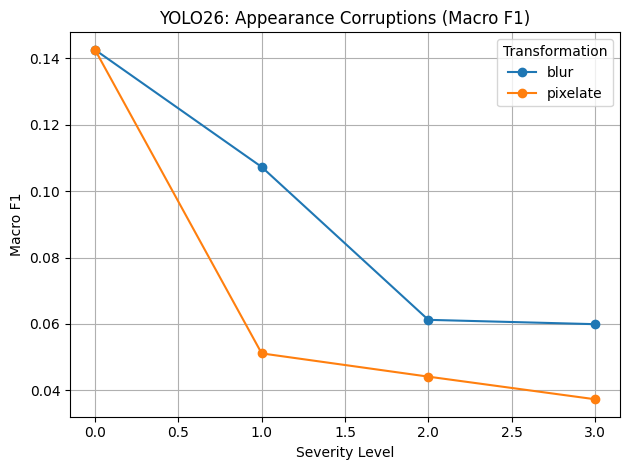

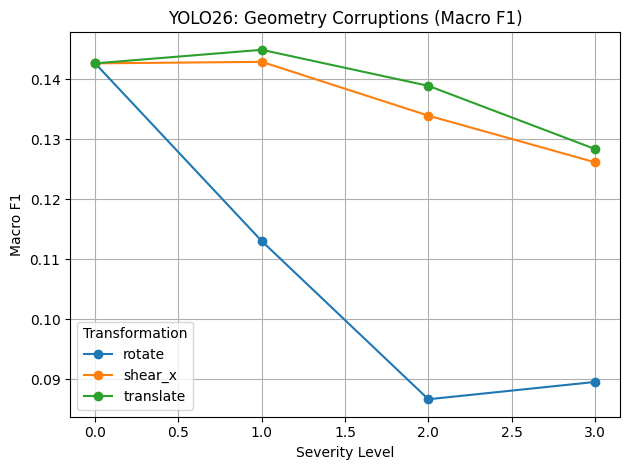

In [26]:
lineplot_by_transform(
    yolo_syn_app,
    "macro_f1",
    "YOLO26: Appearance Corruptions (Macro F1)",
    "Macro F1",
    "synthetic_yolo_appearance_macro_f1.png"
)

lineplot_by_transform(
    yolo_syn_geo,
    "macro_f1",
    "YOLO26: Geometry Corruptions (Macro F1)",
    "Macro F1",
    "synthetic_yolo_geometry_macro_f1.png"
)

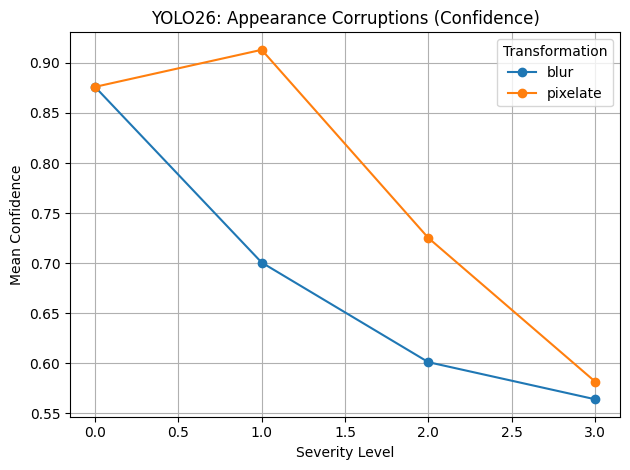

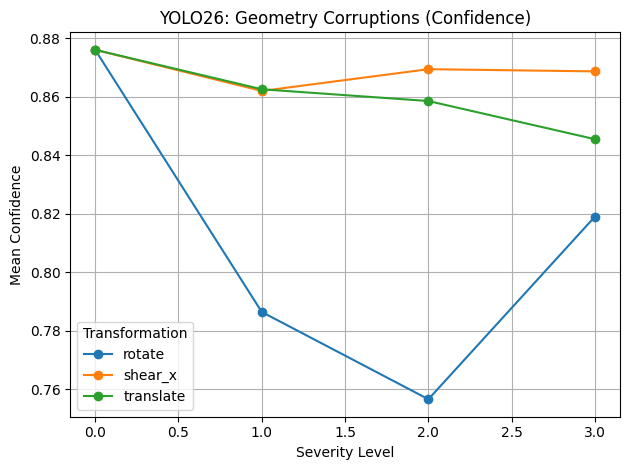

In [27]:
lineplot_by_transform(
    yolo_syn_app,
    "mean_confidence",
    "YOLO26: Appearance Corruptions (Confidence)",
    "Mean Confidence",
    "synthetic_yolo_appearance_confidence.png"
)

lineplot_by_transform(
    yolo_syn_geo,
    "mean_confidence",
    "YOLO26: Geometry Corruptions (Confidence)",
    "Mean Confidence",
    "synthetic_yolo_geometry_confidence.png"
)

In [28]:
# --- OpenCLIP natural summaries ---
nat_clip_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_subtype.csv")
nat_clip_class = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_class.csv")
nat_clip_class_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_class_subtype.csv")

# --- optional: OpenCLIP drift if needed later ---
nat_clip_drift_subtype = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_subtype.csv")
nat_clip_drift_class = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_class.csv")
nat_clip_drift_class_subtype = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_class_subtype.csv")

print("Loaded OpenCLIP natural summaries")
display(nat_clip_subtype.head())

Loaded OpenCLIP natural summaries


,subtype,accuracy,mean_confidence,n
0,abstract,0.935278,0.111627,1097
1,cartoon,0.983666,0.114602,1102
2,painting,0.976548,0.113800,1066
3,real,0.880581,0.111872,1859
4,sketch,0.979827,0.114235,1041


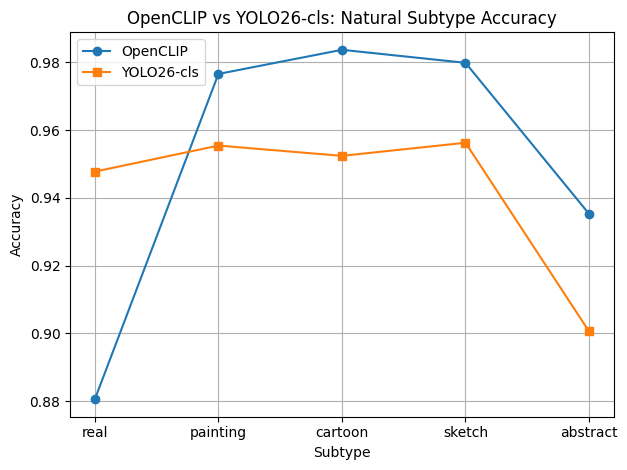

In [29]:
clip_sub = order_subtypes(nat_clip_subtype)
yolo_sub = order_subtypes(yolo_nat_subtype)

plt.figure()
plt.plot(clip_sub["subtype"], clip_sub["accuracy"], marker="o", label="OpenCLIP")
plt.plot(yolo_sub["subtype"], yolo_sub["accuracy"], marker="s", label="YOLO26-cls")
plt.grid(True)
plt.xlabel("Subtype")
plt.ylabel("Accuracy")
plt.title("OpenCLIP vs YOLO26-cls: Natural Subtype Accuracy")
plt.legend()
savefig("natural_openclip_vs_yolo_subtype_accuracy.png")

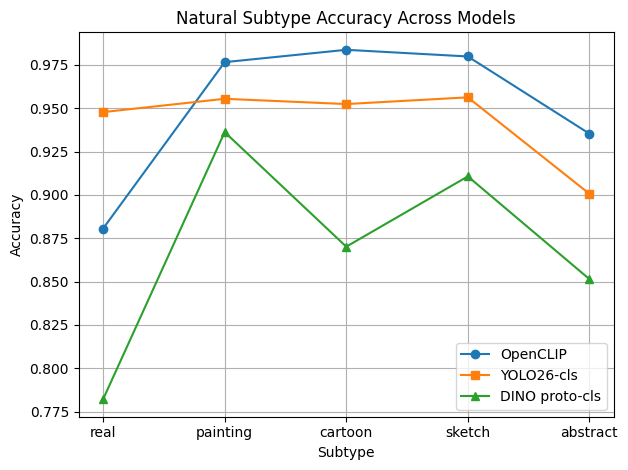

In [30]:
dino_nat_subtype_acc = pd.read_csv(RESULTS_NAT / "dino_natural_accuracy_by_subtype.csv")
dino_nat_subtype_acc = order_subtypes(dino_nat_subtype_acc)

plt.figure()
plt.plot(clip_sub["subtype"], clip_sub["accuracy"], marker="o", label="OpenCLIP")
plt.plot(yolo_sub["subtype"], yolo_sub["accuracy"], marker="s", label="YOLO26-cls")
plt.plot(dino_nat_subtype_acc["subtype"], dino_nat_subtype_acc["accuracy"], marker="^", label="DINO proto-cls")
plt.grid(True)
plt.xlabel("Subtype")
plt.ylabel("Accuracy")
plt.title("Natural Subtype Accuracy Across Models")
plt.legend()
savefig("natural_three_model_subtype_accuracy.png")

In [31]:
# --- Synthetic OpenCLIP summaries ---
sum_app_clip = pd.read_csv(RESULTS_SYN / "summary_corruptions_appearance_openclip.csv")
sum_geo_clip = pd.read_csv(RESULTS_SYN / "summary_corruptions_geometry_openclip.csv")

# --- Optional: synthetic EfficientNet and DINO if you want them later ---
sum_app_eff = pd.read_csv(RESULTS_SYN / "summary_corruptions_appearance_efficientnet.csv")
sum_geo_eff = pd.read_csv(RESULTS_SYN / "summary_corruptions_geometry_efficientnet.csv")

drift_clip_app = pd.read_csv(RESULTS_SYN / "embedding_drift_openclip_appearance.csv")
drift_clip_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_openclip_geometry.csv")
drift_eff_app = pd.read_csv(RESULTS_SYN / "embedding_drift_efficientnet_appearance.csv")
drift_eff_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_efficientnet_geometry.csv")
drift_dino_app = pd.read_csv(RESULTS_SYN / "embedding_drift_dino_appearance.csv")
drift_dino_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_dino_geometry.csv")

print("Loaded synthetic summary tables.")
display(sum_app_clip.head())
display(sum_geo_clip.head())

Loaded synthetic summary tables.


,model,dataset,axis,transform,level,accuracy,mean_confidence,n
0,openclip_vit_b_32,cifar10,appearance,blur,0,0.8885,0.110567,2000
1,openclip_vit_b_32,cifar10,appearance,blur,1,0.6020,0.104962,2000
2,openclip_vit_b_32,cifar10,appearance,blur,2,0.2170,0.101794,2000
3,openclip_vit_b_32,cifar10,appearance,blur,3,0.1505,0.101768,2000
4,openclip_vit_b_32,cifar10,appearance,pixelate,0,0.8885,0.110567,2000


,model,dataset,axis,transform,level,accuracy,mean_confidence,n
0,openclip_vit_b_32,cifar10,geometry,rotate,0,0.8885,0.110567,2000
1,openclip_vit_b_32,cifar10,geometry,rotate,1,0.6600,0.106419,2000
2,openclip_vit_b_32,cifar10,geometry,rotate,2,0.4330,0.104568,2000
3,openclip_vit_b_32,cifar10,geometry,rotate,3,0.5115,0.105150,2000
4,openclip_vit_b_32,cifar10,geometry,shear_x,0,0.8885,0.110567,2000


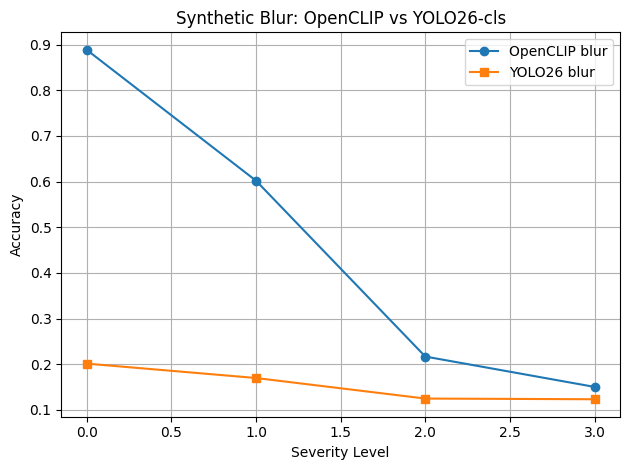

In [32]:
yolo_blur = yolo_syn_app[yolo_syn_app["transform"] == "blur"].sort_values("level")
clip_blur = sum_app_clip[sum_app_clip["transform"] == "blur"].sort_values("level")

plt.figure()
plt.plot(clip_blur["level"], clip_blur["accuracy"], marker="o", label="OpenCLIP blur")
plt.plot(yolo_blur["level"], yolo_blur["accuracy"], marker="s", label="YOLO26 blur")
plt.grid(True)
plt.xlabel("Severity Level")
plt.ylabel("Accuracy")
plt.title("Synthetic Blur: OpenCLIP vs YOLO26-cls")
plt.legend()
savefig("synthetic_blur_openclip_vs_yolo.png")

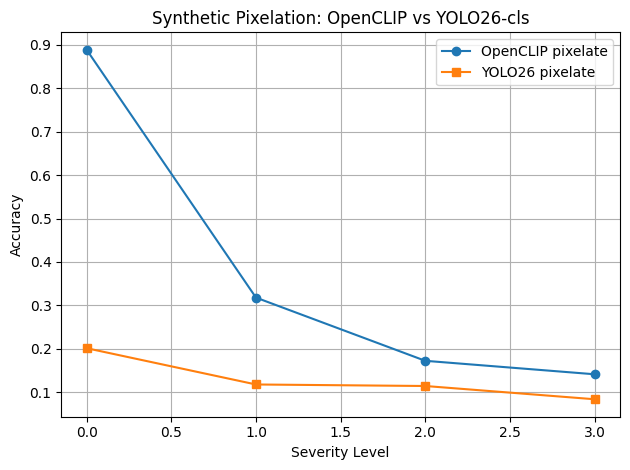

In [33]:
yolo_pix = yolo_syn_app[yolo_syn_app["transform"] == "pixelate"].sort_values("level")
clip_pix = sum_app_clip[sum_app_clip["transform"] == "pixelate"].sort_values("level")

plt.figure()
plt.plot(clip_pix["level"], clip_pix["accuracy"], marker="o", label="OpenCLIP pixelate")
plt.plot(yolo_pix["level"], yolo_pix["accuracy"], marker="s", label="YOLO26 pixelate")
plt.grid(True)
plt.xlabel("Severity Level")
plt.ylabel("Accuracy")
plt.title("Synthetic Pixelation: OpenCLIP vs YOLO26-cls")
plt.legend()
savefig("synthetic_pixelate_openclip_vs_yolo.png")

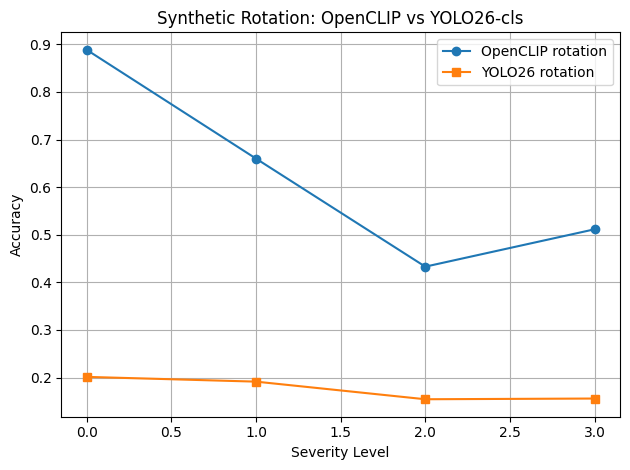

In [34]:
yolo_rot = yolo_syn_geo[yolo_syn_geo["transform"] == "rotate"].sort_values("level")
clip_rot = sum_geo_clip[sum_geo_clip["transform"] == "rotate"].sort_values("level")

plt.figure()
plt.plot(clip_rot["level"], clip_rot["accuracy"], marker="o", label="OpenCLIP rotation")
plt.plot(yolo_rot["level"], yolo_rot["accuracy"], marker="s", label="YOLO26 rotation")
plt.grid(True)
plt.xlabel("Severity Level")
plt.ylabel("Accuracy")
plt.title("Synthetic Rotation: OpenCLIP vs YOLO26-cls")
plt.legend()
savefig("synthetic_rotation_openclip_vs_yolo.png")

In [35]:
def failure_threshold(df, baseline_level=0, metric="accuracy", frac=0.5):
    rows = []
    for transform in sorted(df["transform"].unique()):
        sub = df[df["transform"] == transform].sort_values("level")
        baseline = float(sub[sub["level"] == baseline_level][metric].iloc[0])
        threshold = frac * baseline

        fail_level = None
        for _, r in sub.iterrows():
            if r["level"] > baseline_level and r[metric] <= threshold:
                fail_level = int(r["level"])
                break

        rows.append({
            "transform": transform,
            "baseline_metric": baseline,
            "threshold_metric": threshold,
            "failure_level": fail_level,
        })

    return pd.DataFrame(rows)

yolo_fail_app = failure_threshold(yolo_syn_app, metric="accuracy")
yolo_fail_geo = failure_threshold(yolo_syn_geo, metric="accuracy")

print("YOLO appearance failure levels")
display(yolo_fail_app)

print("YOLO geometry failure levels")
display(yolo_fail_geo)

YOLO appearance failure levels


,transform,baseline_metric,threshold_metric,failure_level
0,blur,0.2015,0.10075,NaN
1,pixelate,0.2015,0.10075,3.0


YOLO geometry failure levels


,transform,baseline_metric,threshold_metric,failure_level
0,rotate,0.2015,0.10075,None
1,shear_x,0.2015,0.10075,None
2,translate,0.2015,0.10075,None


In [36]:
yolo_fail_app.to_csv(RESULTS_NAT / "failure_corruptions_appearance_yolo26.csv", index=False)
yolo_fail_geo.to_csv(RESULTS_NAT / "failure_corruptions_geometry_yolo26.csv", index=False)

In [38]:
def relative_drop_table(df, metric="accuracy"):
    rows = []
    for transform in sorted(df["transform"].unique()):
        sub = df[df["transform"] == transform].sort_values("level")
        baseline = float(sub[sub["level"] == 0][metric].iloc[0])

        for _, r in sub.iterrows():
            drop = (baseline - float(r[metric])) / baseline if baseline > 0 else np.nan
            rows.append({
                "transform": transform,
                "level": int(r["level"]),
                metric: float(r[metric]),
                "relative_drop": drop,
            })

    return pd.DataFrame(rows)

yolo_drop_app = relative_drop_table(yolo_syn_app, metric="accuracy")
yolo_drop_geo = relative_drop_table(yolo_syn_geo, metric="accuracy")

display(yolo_drop_app.head(20))
display(yolo_drop_geo.head(20))

,transform,level,accuracy,relative_drop
0,blur,0,0.2015,0.000000
1,blur,1,0.1700,0.156328
2,blur,2,0.1250,0.379653
3,blur,3,0.1235,0.387097
4,pixelate,0,0.2015,0.000000
5,pixelate,1,0.1180,0.414392
6,pixelate,2,0.1145,0.431762
7,pixelate,3,0.0840,0.583127


,transform,level,accuracy,relative_drop
0,rotate,0,0.2015,0.000000
1,rotate,1,0.1915,0.049628
2,rotate,2,0.1545,0.233251
3,rotate,3,0.1560,0.225806
4,shear_x,0,0.2015,0.000000
5,shear_x,1,0.1930,0.042184
6,shear_x,2,0.1820,0.096774
7,shear_x,3,0.1735,0.138958
8,translate,0,0.2015,0.000000
9,translate,1,0.2070,-0.027295


In [39]:
print("YOLO natural overall:")
display(yolo_nat_overall)

print("YOLO subtype summary:")
display(yolo_nat_subtype.sort_values("subtype"))

print("YOLO class summary:")
display(yolo_nat_class.sort_values("true_label_name"))

print("YOLO appearance failure levels:")
display(yolo_fail_app)

print("YOLO geometry failure levels:")
display(yolo_fail_geo)

YOLO natural overall:


,accuracy,macro_f1,n
0,0.943194,0.947038,933


YOLO subtype summary:


,subtype,accuracy,macro_f1,mean_confidence,n
0,abstract,0.900621,0.910121,0.948510,161.0
1,cartoon,0.952381,0.942111,0.973489,168.0
2,painting,0.955414,0.947102,0.981080,157.0
3,real,0.947735,0.962141,0.961453,287.0
4,sketch,0.956250,0.951593,0.968317,160.0


YOLO class summary:


,true_label_name,accuracy,mean_confidence,n
0,airplane,0.913793,0.934555,116.0
1,automobile,0.938596,0.951923,114.0
2,bird,0.915094,0.957401,106.0
3,cat,0.945946,0.971666,111.0
4,deer,0.935484,0.979700,93.0
5,dog,0.975309,0.968127,81.0
6,frog,1.000000,0.995226,80.0
7,horse,0.948052,0.970203,77.0
8,ship,0.961538,0.972914,78.0
9,truck,0.922078,0.975912,77.0


YOLO appearance failure levels:


,transform,baseline_metric,threshold_metric,failure_level
0,blur,0.2015,0.10075,NaN
1,pixelate,0.2015,0.10075,3.0


YOLO geometry failure levels:


,transform,baseline_metric,threshold_metric,failure_level
0,rotate,0.2015,0.10075,None
1,shear_x,0.2015,0.10075,None
2,translate,0.2015,0.10075,None


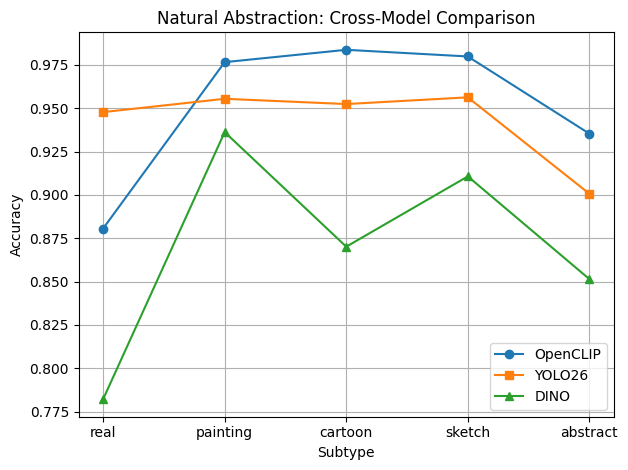

In [40]:
# Order data
clip_sub = order_subtypes(nat_clip_subtype)
yolo_sub = order_subtypes(yolo_nat_subtype)
dino_sub = order_subtypes(dino_nat_subtype_acc)

plt.figure()

plt.plot(clip_sub["subtype"], clip_sub["accuracy"], marker="o", label="OpenCLIP")
plt.plot(yolo_sub["subtype"], yolo_sub["accuracy"], marker="s", label="YOLO26")
plt.plot(dino_sub["subtype"], dino_sub["accuracy"], marker="^", label="DINO")

plt.grid(True)
plt.xlabel("Subtype")
plt.ylabel("Accuracy")
plt.title("Natural Abstraction: Cross-Model Comparison")
plt.legend()

savefig("natural_cross_model_accuracy.png")

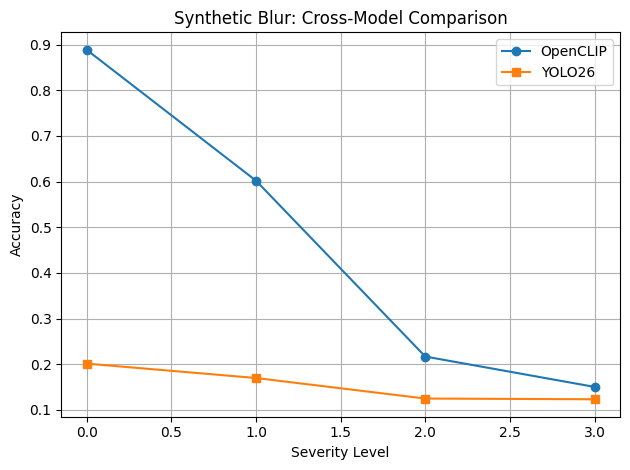

In [41]:
clip_blur = sum_app_clip[sum_app_clip["transform"] == "blur"].sort_values("level")
yolo_blur = yolo_syn_app[yolo_syn_app["transform"] == "blur"].sort_values("level")

plt.figure()

plt.plot(clip_blur["level"], clip_blur["accuracy"], marker="o", label="OpenCLIP")
plt.plot(yolo_blur["level"], yolo_blur["accuracy"], marker="s", label="YOLO26")

plt.grid(True)
plt.xlabel("Severity Level")
plt.ylabel("Accuracy")
plt.title("Synthetic Blur: Cross-Model Comparison")
plt.legend()

savefig("synthetic_blur_cross_model.png")

In [42]:
top_confusions(yolo_conf_overall, 10)

,true,pred,count
0,airplane,automobile,6
5,automobile,airplane,6
30,truck,automobile,5
7,bird,airplane,4
9,bird,cat,2
15,cat,dog,2
20,deer,dog,2
17,deer,airplane,2
27,ship,airplane,2
8,bird,automobile,1


In [43]:
from ultralytics import YOLO
from pathlib import Path
import os

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

MODEL_PATH = ROOT / "natural_abstraction" / "yolo_runs" / "yolo26n_cls_mirrored" / "weights" / "best.pt"

print("cwd:", Path.cwd())
print("ROOT:", ROOT)
print("MODEL_PATH:", MODEL_PATH)
print("exists:", MODEL_PATH.exists())

model = YOLO(str(MODEL_PATH))

print("model.names =", model.names)
print("expected CLASS_ORDER =", [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
])

cwd: c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\notebooks
ROOT: c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project
MODEL_PATH: c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\natural_abstraction\yolo_runs\yolo26n_cls_mirrored\weights\best.pt
exists: True
model.names = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}
expected CLASS_ORDER = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
